   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


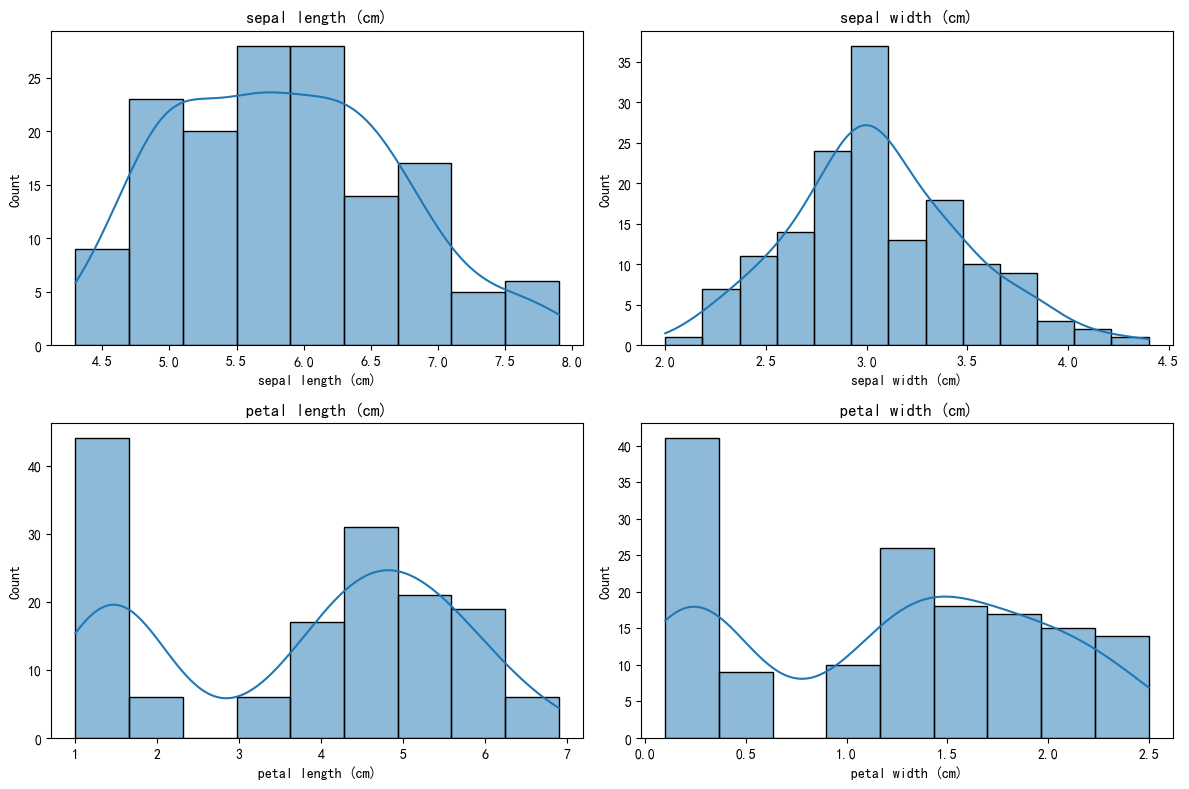

NameError: name 'y_pred' is not defined

In [1]:
# 實驗四：貝氏分類（Gaussian Naive Bayes）

# 步驟 1：環境準備與資料讀取
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib as mpl

# 設定中文顯示
mpl.rcParams['font.family'] = 'SimHei'
mpl.rcParams['axes.unicode_minus'] = False

# 步驟 2：資料讀取與視覺化
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# 資料摘要
print(df.head())

# 資料視覺化
import seaborn as sns

plt.figure(figsize=(12, 8))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'{feature}')
plt.tight_layout()
plt.show()

# 步驟 3：數據預處理
X = df[iris.feature_names]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 步驟 4：建立 Gaussian Naive Bayes 模型
model = GaussianNB()
model.fit(X_train_scaled, y_train)

# 預測
pred = model.predict(X_test_scaled)

# 模型評估
accuracy = accuracy_score(y_test, y_pred)
print('模型準確率:', accuracy_score(y_test, pred))
print("\n分類報告:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# 混淆矩陣
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('預測類別')
plt.ylabel('真實類別')
plt.title('混淆矩陣')
plt.show()

# 步驟 5：視覺化貝氏決策邊界（選取兩個特徵）
feature_indices = [2, 3]  # 使用 petal length 和 petal width
X_two = X[:, feature_indices]
X_train_two, X_test_two, y_train_two, y_test_two = train_test_split(X_two, y, test_size=0.3, random_state=42)

scaler_two = StandardScaler()
X_train_two_scaled = scaler.fit_transform(X_train_two)

model_two = GaussianNB()
model_two.fit(X_train_two, y_train)

# 繪製決策邊界
x_min, x_max = X_train_two[:, 0].min() - 1, X_train_two[:, 0].max() + 1
y_min, y_max = X_train_two[:, 1].min() - 1, X_train_two[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = model_two.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Pastel1')
sns.scatterplot(x=X_train_two[:, 0], y=X_train_two[:, 1], hue=y_train,
                palette='Set1', edgecolor='k')
plt.xlabel('花瓣長度')
plt.ylabel('花瓣寬度')
plt.title('Gaussian Naive Bayes 決策邊界')
plt.show()